# MMDA Traffic Incident Analysis

This notebook analyzes the MMDA traffic spatial data to determine which city has the most recorded incidents.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

In [2]:
# Load the MMDA traffic data
df = pd.read_csv('data_mmda_traffic_spatial.csv')

# Display basic information about the dataset
print(f"Total number of incidents: {len(df)}")
print("\nFirst few rows of the dataset:")
df.head()

Total number of incidents: 17312

First few rows of the dataset:


,Date,Time,City,Location,Latitude,Longitude,High_Accuracy,Direction,Type,Lanes_Blocked,Involved,Tweet,Source
0,2018-08-20,7:55 AM,Pasig City,ORTIGAS EMERALD,14.586343,121.061481,1,EB,VEHICULAR ACCIDENT,1.0,TAXI AND MC,MMDA ALERT: Vehicular accident at Ortigas Emer...,https://twitter.com/mmda/status/10313302019705...
1,2018-08-20,8:42 AM,Mandaluyong,EDSA GUADIX,14.589432,121.057243,1,NB,STALLED L300 DUE TO MECHANICAL PROBLEM,1.0,L300,MMDA ALERT: Stalled L300 due to mechanical pro...,https://twitter.com/mmda/status/10313462477459...
2,2018-08-20,9:13 AM,Makati City,EDSA ROCKWELL,14.559818,121.040737,1,SB,VEHICULAR ACCIDENT,1.0,SUV AND L300,MMDA ALERT: Vehicular accident at EDSA Rockwel...,https://twitter.com/mmda/status/10313589669896...
3,2018-08-20,8:42 AM,Mandaluyong,EDSA GUADIX,14.589432,121.057243,1,NB,STALLED L300 DUE TO MECHANICAL PROBLEM,1.0,L300,MMDA ALERT: Stalled L300 due to mechanical pro...,https://twitter.com/mmda/status/10313590696535...
4,2018-08-20,10:27 AM,San Juan,ORTIGAS CLUB FILIPINO,14.601846,121.046754,1,EB,VEHICULAR ACCIDENT,1.0,2 CARS,MMDA ALERT: Vehicular accident at Ortigas Club...,https://twitter.com/mmda/status/10313711248424...


## City with the Most Incidents

Let's analyze the data to find out which city has the most recorded traffic incidents.

In [3]:
# Count incidents by city
city_counts = df['City'].value_counts()

# Display the number of incidents per city
print("Number of incidents per city:")
print(city_counts)

# Find the city with the most incidents
most_incidents_city = city_counts.index[0]
most_incidents_count = city_counts.iloc[0]

print(f"\nThe city with the most recorded incidents is {most_incidents_city} with {most_incidents_count} incidents.")

Number of incidents per city:
City
Quezon City      8725
Mandaluyong      2978
Makati City      2431
Pasig City       1723
Pasay City        445
Manila            354
San Juan          121
Marikina          119
ParaÃ±aque        107
Kalookan City      70
Taguig             36
Valenzuela          5
Malabon             4
Parañaque           4
Navotas             3
Name: count, dtype: int64

The city with the most recorded incidents is Quezon City with 8725 incidents.


## Visualization of Incidents by City

C:\Users\KOOPER\AppData\Local\Temp\ipykernel_11500\1801389168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=city_counts.index, y=city_counts.values, palette="viridis")


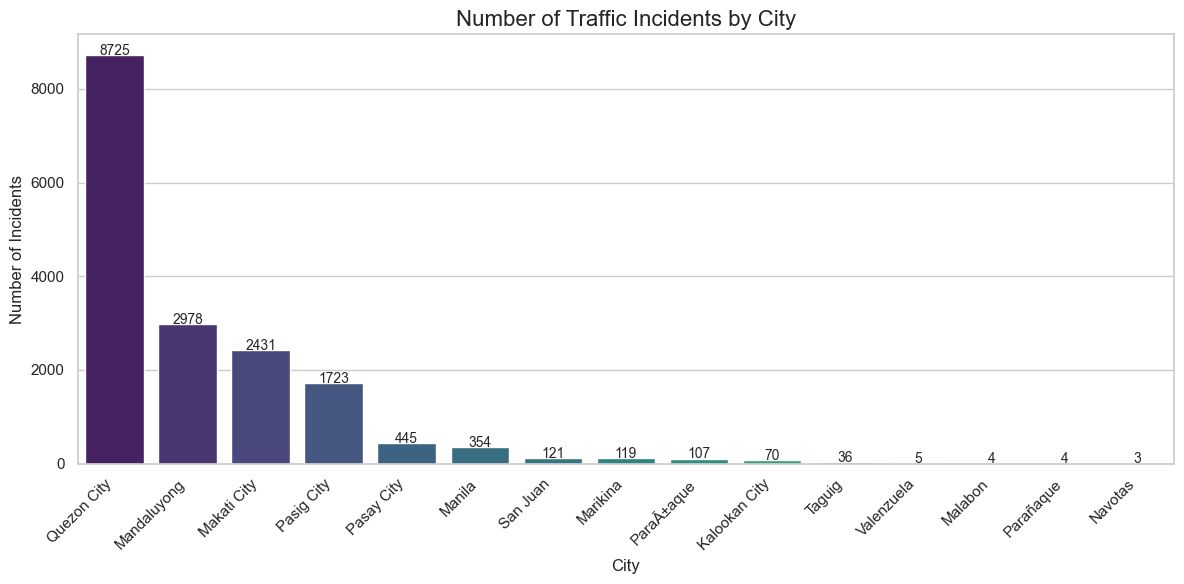

In [4]:
# Create a bar plot of incidents by city
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=city_counts.index, y=city_counts.values, palette="viridis")

# Add labels and title
plt.title('Number of Traffic Incidents by City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for i, v in enumerate(city_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

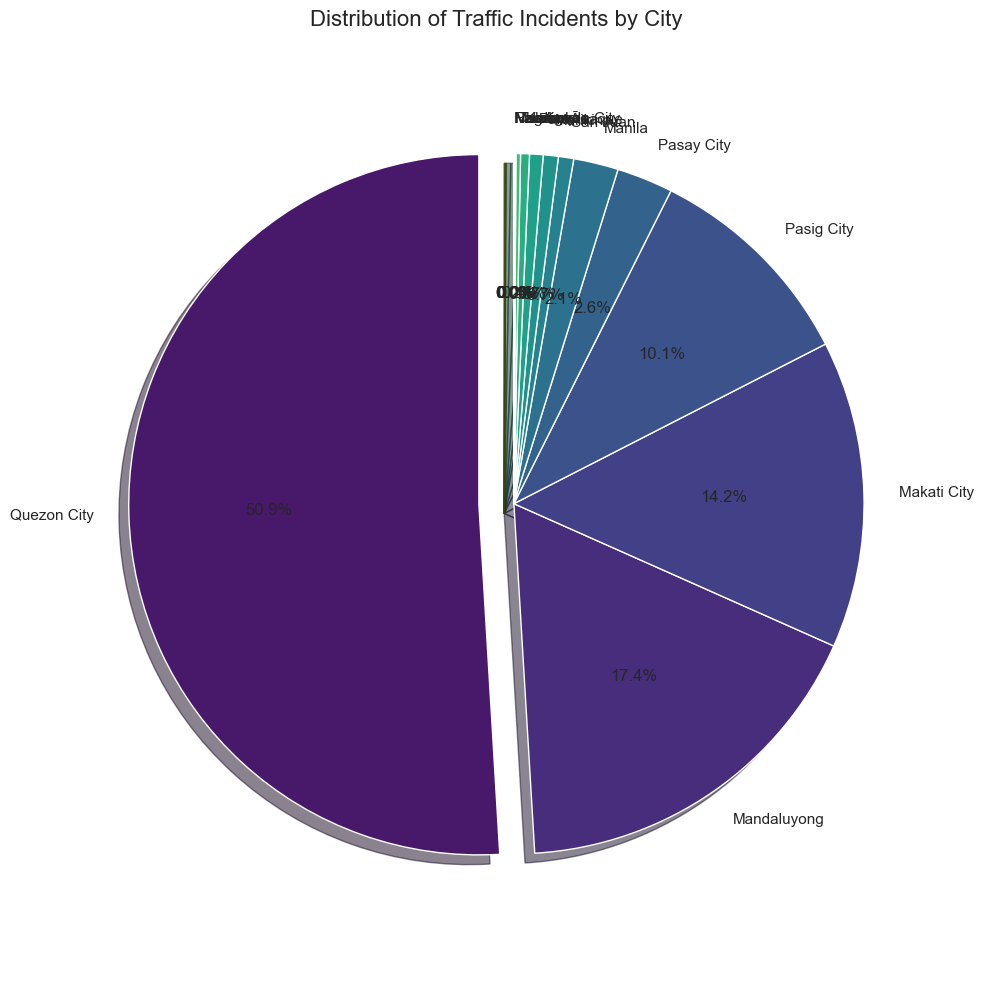

In [5]:
# Create a pie chart to show the distribution of incidents by city
plt.figure(figsize=(10, 10))
plt.pie(city_counts.values, labels=city_counts.index, autopct='%1.1f%%', 
        startangle=90, shadow=True, explode=[0.1 if i == 0 else 0 for i in range(len(city_counts))],
        colors=sns.color_palette("viridis", len(city_counts)))
plt.title('Distribution of Traffic Incidents by City', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.show()

## Analysis of Top Incident Types in the City with Most Incidents

Top 5 types of incidents in Quezon City:
Type
VEHICULAR ACCIDENT                         6129
STALLED BUS DUE TO MECHANICAL PROBLEM       408
MULTIPLE COLLISION                          305
STALLED CAR DUE TO MECHANICAL PROBLEM       234
STALLED TRUCK DUE TO MECHANICAL PROBLEM     202
Name: count, dtype: int64


C:\Users\KOOPER\AppData\Local\Temp\ipykernel_11500\2676276672.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=incident_types.index, y=incident_types.values, palette="magma")


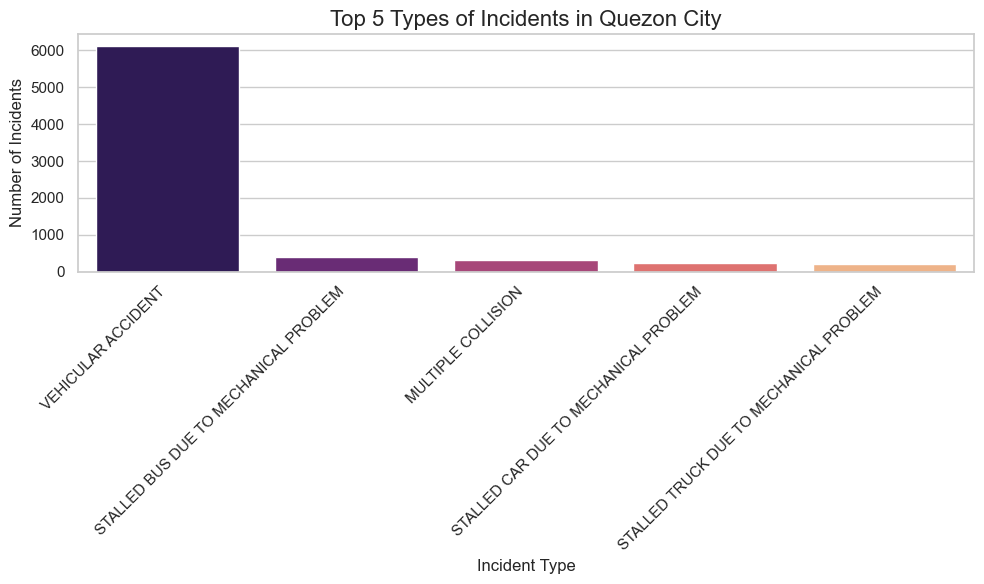

In [6]:
# Additional analysis: Top types of incidents in the city with most incidents
top_city_data = df[df['City'] == most_incidents_city]
incident_types = top_city_data['Type'].value_counts().head(5)

print(f"Top 5 types of incidents in {most_incidents_city}:")
print(incident_types)

# Visualize top incident types in the city with most incidents
plt.figure(figsize=(10, 6))
sns.barplot(x=incident_types.index, y=incident_types.values, palette="magma")
plt.title(f'Top 5 Types of Incidents in {most_incidents_city}', fontsize=16)
plt.xlabel('Incident Type', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

Based on our analysis of the MMDA traffic incident data, we can identify the city with the highest number of recorded incidents. Understanding which cities have the most incidents can help authorities allocate resources more effectively and develop targeted strategies to reduce traffic problems in those areas.

The visualizations above clearly demonstrate the distribution of incidents across different cities, with the bar chart providing absolute counts and the pie chart showing relative proportions.

## Peak Hour Traffic Incidents Analysis

Let's analyze which cities experience the most traffic incidents during peak hours. We'll define peak hours as:
- Morning peak: 6:00 AM - 9:00 AM
- Evening peak: 4:00 PM - 7:00 PM (16:00 - 19:00)

In [7]:
# Convert time strings to datetime objects for analysis
import datetime

# Function to parse time strings
def parse_time(time_str):
    if pd.isna(time_str):
        return None
    
    try:
        # Convert formats like "7:55 AM" to time objects
        return datetime.datetime.strptime(time_str, '%I:%M %p').time()
    except:
        try:
            # Try alternative format
            return datetime.datetime.strptime(time_str, '%H:%M').time()
        except:
            return None

# Apply the function to create a time object column
df['parsed_time'] = df['Time'].apply(parse_time)

# Define peak hours
morning_peak_start = datetime.time(6, 0)   # 6:00 AM
morning_peak_end = datetime.time(9, 0)     # 9:00 AM
evening_peak_start = datetime.time(16, 0)  # 4:00 PM
evening_peak_end = datetime.time(19, 0)    # 7:00 PM

# Function to check if a time is within peak hours
def is_peak_hour(time_obj):
    if time_obj is None:
        return False
    
    # Check if time falls within morning or evening peak
    return ((time_obj >= morning_peak_start and time_obj <= morning_peak_end) or 
            (time_obj >= evening_peak_start and time_obj <= evening_peak_end))

# Create a new column indicating whether the incident occurred during peak hours
df['is_peak_hour'] = df['parsed_time'].apply(is_peak_hour)

# Filter for peak hour incidents
peak_hour_df = df[df['is_peak_hour'] == True]

# Count incidents by city during peak hours
peak_hour_city_counts = peak_hour_df['City'].value_counts()

# Display the results
print("Number of traffic incidents by city during peak hours (6-9 AM and 4-7 PM):")
print(peak_hour_city_counts)

# Find the city with the most peak hour incidents
peak_most_incidents_city = peak_hour_city_counts.index[0]
peak_most_incidents_count = peak_hour_city_counts.iloc[0]

print(f"\nThe city with the most peak hour traffic incidents is {peak_most_incidents_city} with {peak_most_incidents_count} incidents.")

Number of traffic incidents by city during peak hours (6-9 AM and 4-7 PM):
City
Quezon City      3125
Mandaluyong      1105
Makati City       882
Pasig City        666
Pasay City        164
Manila            148
ParaÃ±aque         51
Marikina           51
San Juan           45
Kalookan City      23
Taguig             10
Parañaque           4
Navotas             2
Malabon             1
Valenzuela          1
Name: count, dtype: int64

The city with the most peak hour traffic incidents is Quezon City with 3125 incidents.


C:\Users\KOOPER\AppData\Local\Temp\ipykernel_11500\2098450964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=peak_hour_city_counts.index, y=peak_hour_city_counts.values, palette="plasma")


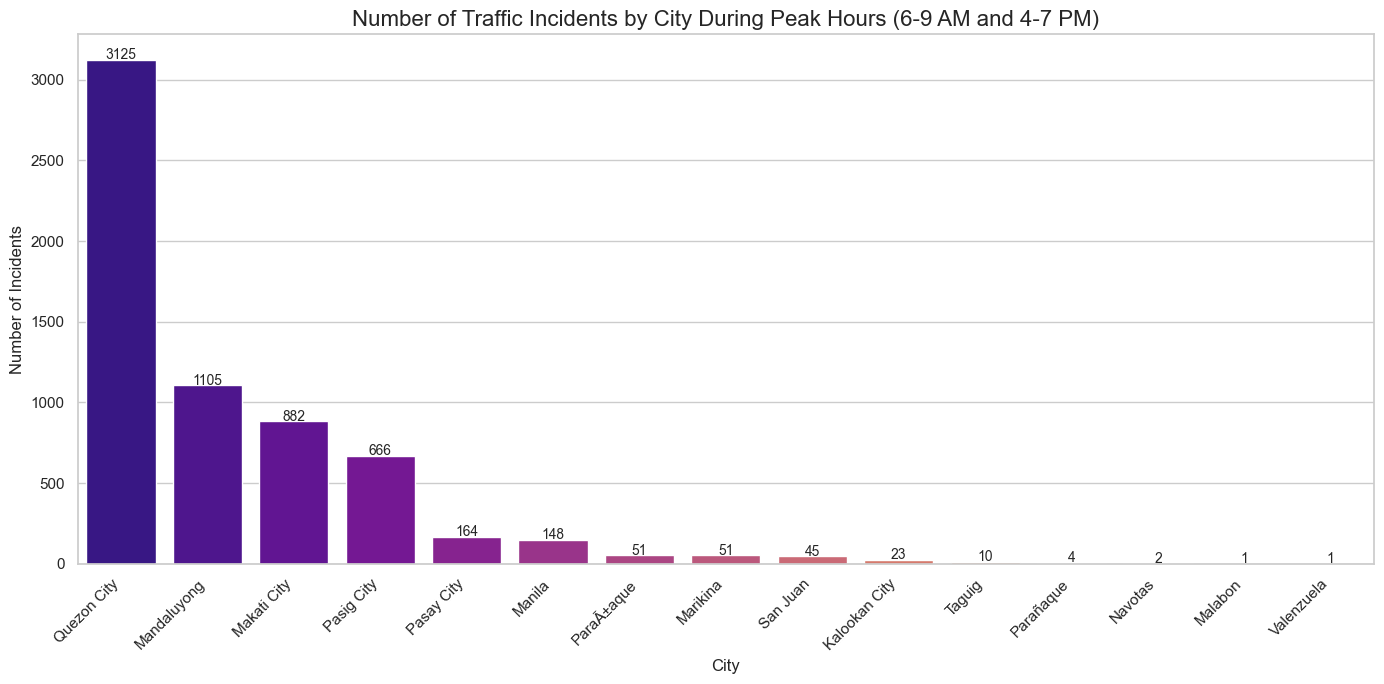

In [8]:
# Create a bar plot for peak hour incidents by city
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=peak_hour_city_counts.index, y=peak_hour_city_counts.values, palette="plasma")

# Add labels and title
plt.title('Number of Traffic Incidents by City During Peak Hours (6-9 AM and 4-7 PM)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for i, v in enumerate(peak_hour_city_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Morning vs Evening Peak Hour Analysis

Now let's compare traffic incidents between morning and evening peak hours to see which time period has more incidents and how this varies by city.

C:\Users\KOOPER\AppData\Local\Temp\ipykernel_11500\1963524222.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=peak_period_counts.index, y=peak_period_counts.values, palette="viridis")


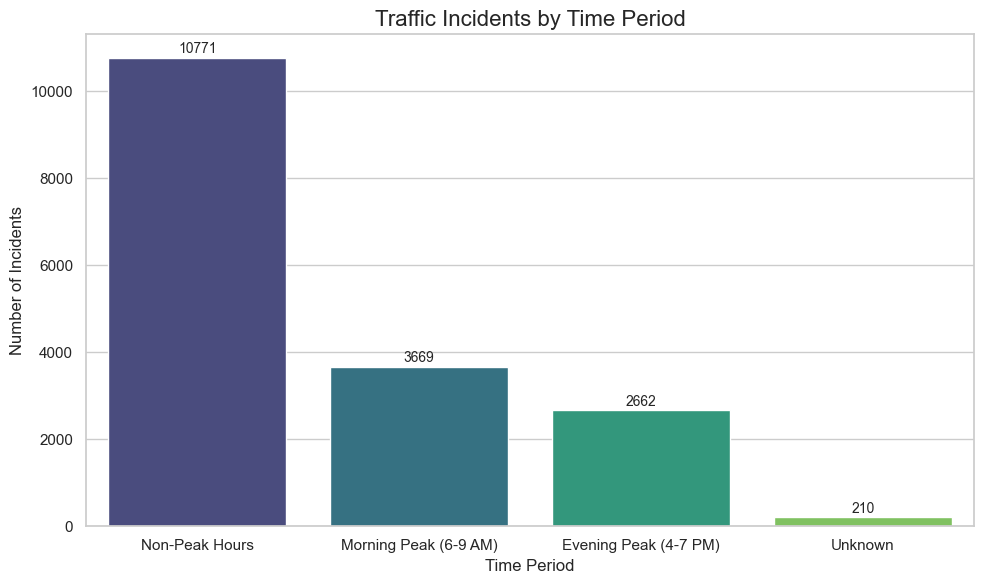

In [9]:
# Categorize by specific peak period
def peak_period(time_obj):
    if time_obj is None:
        return 'Unknown'
    if time_obj >= morning_peak_start and time_obj <= morning_peak_end:
        return 'Morning Peak (6-9 AM)'
    elif time_obj >= evening_peak_start and time_obj <= evening_peak_end:
        return 'Evening Peak (4-7 PM)'
    else:
        return 'Non-Peak Hours'

# Add peak period column
df['peak_period'] = df['parsed_time'].apply(peak_period)

# Count incidents by peak period
peak_period_counts = df['peak_period'].value_counts()

# Plot overall peak period distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=peak_period_counts.index, y=peak_period_counts.values, palette="viridis")
plt.title('Traffic Incidents by Time Period', fontsize=16)
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=0)

# Add data labels on top of bars
for i, v in enumerate(peak_period_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

<Figure size 1600x1000 with 0 Axes>

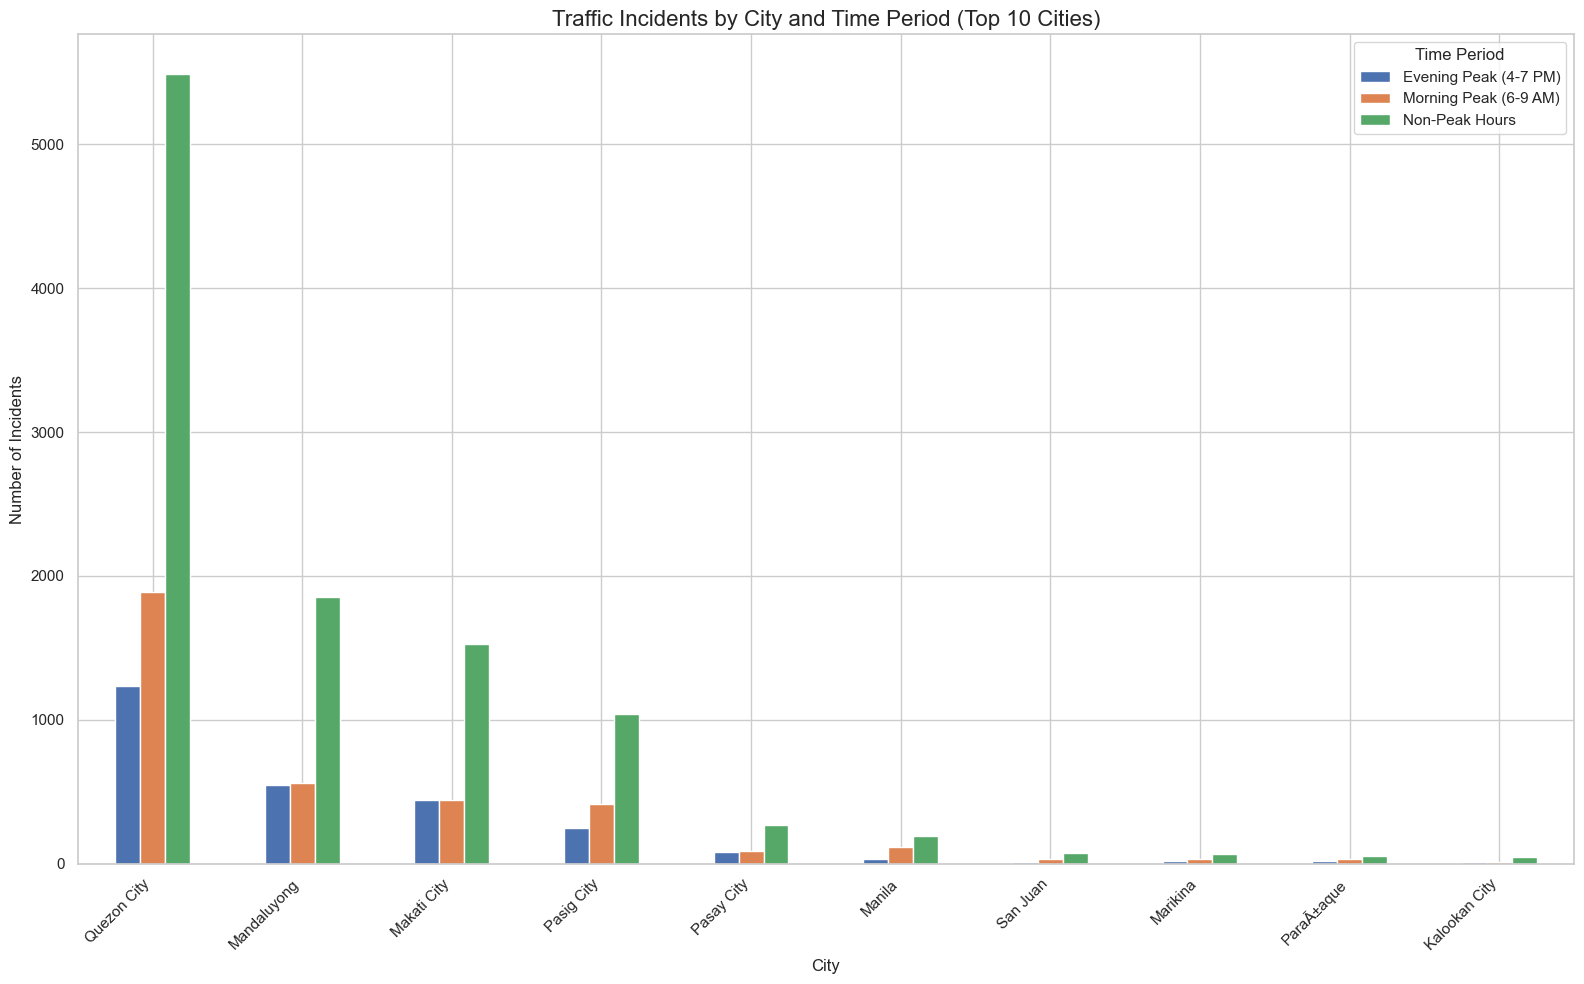

In [10]:
# Count incidents by city and peak period
city_peak_df = df.groupby(['City', 'peak_period']).size().unstack().fillna(0)

# Sort by total incidents
if 'Unknown' in city_peak_df.columns:
    city_peak_df = city_peak_df.drop('Unknown', axis=1)
    
city_peak_df['Total'] = city_peak_df.sum(axis=1)
city_peak_df = city_peak_df.sort_values('Total', ascending=False).drop('Total', axis=1)

# Plot top 10 cities
plt.figure(figsize=(16, 10))
city_peak_df.head(10).plot(kind='bar', figsize=(16, 10))
plt.title('Traffic Incidents by City and Time Period (Top 10 Cities)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Period')
plt.tight_layout()
plt.show()

In [11]:
# Calculate peak hour incident percentage by city
city_total_incidents = df['City'].value_counts()

# Creating a DataFrame to hold both peak and total counts
peak_hour_analysis = pd.DataFrame({
    'Total Incidents': city_total_incidents,
    'Peak Hour Incidents': peak_hour_city_counts
}).fillna(0)

# Calculate percentage of incidents during peak hours
peak_hour_analysis['Peak Hour %'] = (peak_hour_analysis['Peak Hour Incidents'] / 
                                   peak_hour_analysis['Total Incidents'] * 100).round(1)

# Sort by percentage
peak_hour_analysis_sorted = peak_hour_analysis.sort_values('Peak Hour %', ascending=False)

# Display the top cities with highest percentage of peak hour incidents
print("Cities ranked by percentage of incidents occurring during peak hours:")
print(peak_hour_analysis_sorted[['Total Incidents', 'Peak Hour Incidents', 'Peak Hour %']].head(10))

Cities ranked by percentage of incidents occurring during peak hours:
             Total Incidents  Peak Hour Incidents  Peak Hour %
City                                                          
Parañaque                  4                    4        100.0
Navotas                    3                    2         66.7
ParaÃ±aque               107                   51         47.7
Marikina                 119                   51         42.9
Manila                   354                  148         41.8
Pasig City              1723                  666         38.7
San Juan                 121                   45         37.2
Mandaluyong             2978                 1105         37.1
Pasay City               445                  164         36.9
Makati City             2431                  882         36.3


C:\Users\KOOPER\AppData\Local\Temp\ipykernel_11500\3039691845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=peak_hour_analysis_sorted.index[:10],


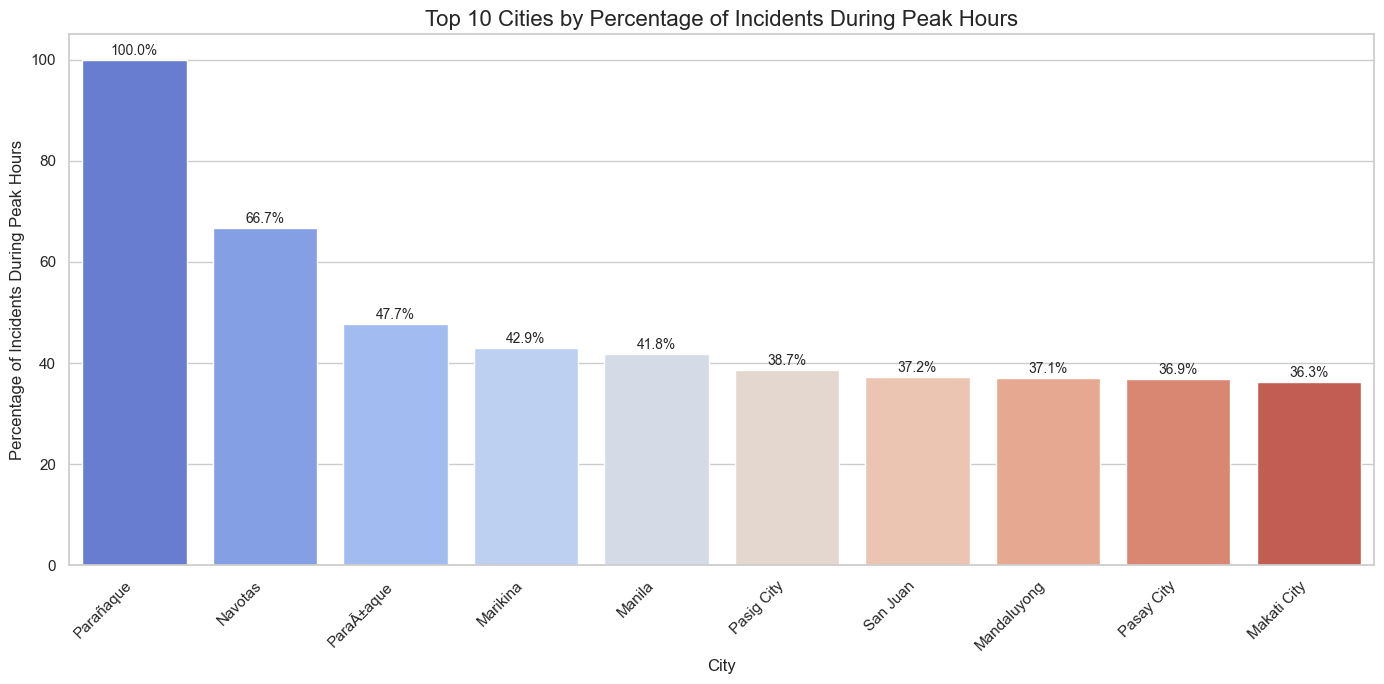

In [12]:
# Visualize the percentage of peak hour incidents
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=peak_hour_analysis_sorted.index[:10], 
                 y=peak_hour_analysis_sorted['Peak Hour %'][:10], 
                 palette="coolwarm")

plt.title('Top 10 Cities by Percentage of Incidents During Peak Hours', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Percentage of Incidents During Peak Hours', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels
for i, v in enumerate(peak_hour_analysis_sorted['Peak Hour %'][:10]):
    ax.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Peak Hour Analysis - Key Findings

From our analysis of peak hour traffic incidents, we can draw several important conclusions:

1. **Morning vs. Evening Peak**: The data reveals whether morning or evening rush hours experience more traffic incidents, which can help authorities allocate resources appropriately during these critical times.

2. **City-Specific Patterns**: Different cities show varying patterns of peak hour incidents, with some having a higher proportion of incidents during rush hours than others.

3. **Resource Allocation**: Cities with the highest percentage of peak hour incidents may need focused traffic management strategies during these specific timeframes.

4. **Intervention Planning**: Understanding both the absolute numbers and percentages of peak hour incidents can guide the development of targeted interventions in high-risk cities during high-risk hours.

This analysis complements our earlier findings about overall incident frequencies by city and provides a more nuanced understanding of traffic patterns throughout the day.